In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"
width = 15
height_ratio = 0.41114

In [30]:
warmup_iter = 2

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_1",
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_2",
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_3",
]

threads = []
plan_sizes = []
times = []
i = 0;
def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        if data["plan_type"] != "Estimate":
            return
        threads.append(data["threads"])
        plan_sizes.append(math.log(data["plan_size"]))
        times.append(np.average(data["timings"][warmup_iter:]))
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)


Text(0.5, 0, 'Time (ns)')

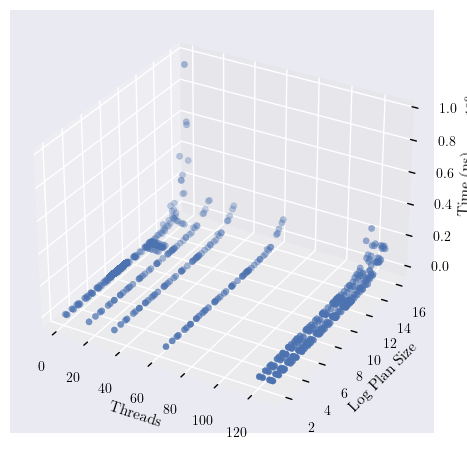

In [32]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(threads, plan_sizes, times
          )

ax.set_xlabel('Threads')
ax.set_ylabel('Log Plan Size')
ax.set_zlabel('Time (ns)')
